# Trabajo Práctico 4 — Aprendizaje No-Supervisado
## Ejercicio 1: Inspección de los datos

---

**Dataset:**   
**Objetivo:** Explorar la naturaleza del dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Enable autoreload for automatic updates of imported modules
%load_ext autoreload
%autoreload 2

# Add src folder to path
import sys, os
ruta_src = os.path.abspath("src")
sys.path.append(ruta_src)

import utils, data_splitting, models, trainer

In [2]:
import torch

print(sys.executable)
print(torch.__version__)
print(torch.cuda.is_available())

c:\Users\pazbi\OneDrive\Escritorio\ml\ml_tp4\torch_env\Scripts\python.exe
2.12.0+cpu
False


In [3]:
np.random.seed(42)

In [4]:
# load data frame
df = pd.read_csv('data/raw/fashion_mnist_subset.csv')

In [5]:
# separate features and label
y = df["label"].values
X = df.drop("label", axis=1).values

In [6]:
# dataset summary 
summary_data, summary_labels = utils.dataset_summary(X, y)

In [7]:
display(summary_data)

,Métrica,Valor
0,Samples,"25,000"
1,Features,784 (28x28 px)
2,Classes,10
3,Pixel range,"[0.0, 1.0]"
4,Dtype,float64
5,NaN values,0
6,Balance,uniform


In [8]:
display(summary_labels)

,Class ID,Name,Count,Pct (%)
0,0,T-shirt/top,2500,10.0
1,1,Trouser,2500,10.0
2,2,Pullover,2500,10.0
3,3,Dress,2500,10.0
4,4,Coat,2500,10.0
5,5,Sandal,2500,10.0
6,6,Shirt,2500,10.0
7,7,Sneaker,2500,10.0
8,8,Bag,2500,10.0
9,9,Ankle boot,2500,10.0


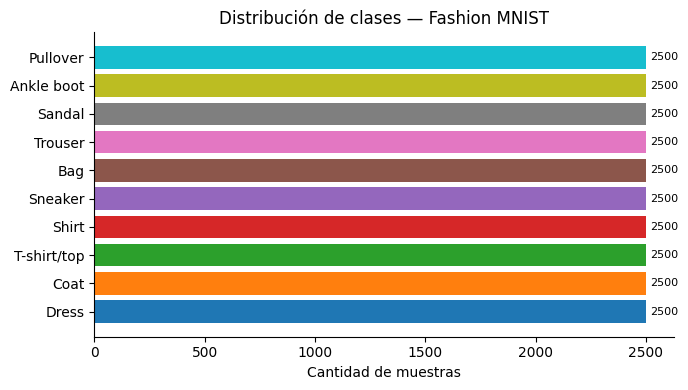

In [9]:
# show classes proportions
utils.show_proportions(df)

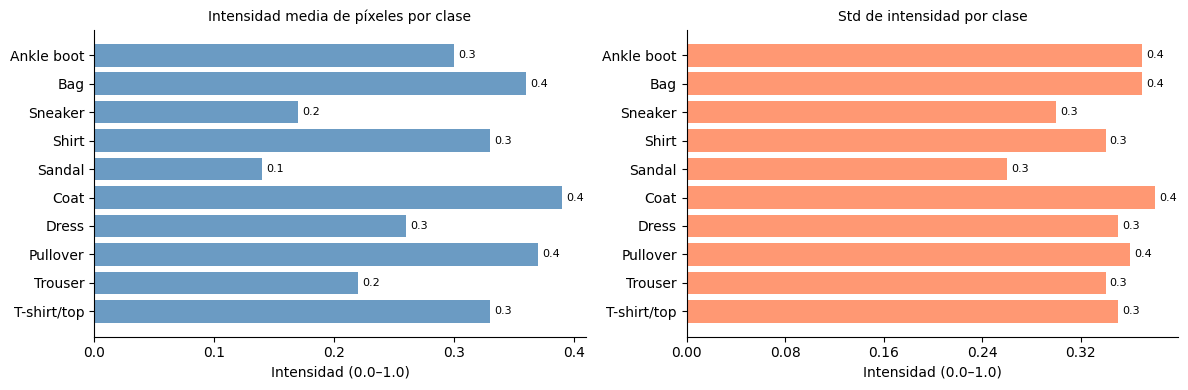

,class,mean_px,std_px
0,T-shirt/top,0.33,0.35
1,Trouser,0.22,0.34
2,Pullover,0.37,0.36
3,Dress,0.26,0.35
4,Coat,0.39,0.38
5,Sandal,0.14,0.26
6,Shirt,0.33,0.34
7,Sneaker,0.17,0.30
8,Bag,0.36,0.37
9,Ankle boot,0.30,0.37


In [10]:
pixel_stats = utils.analyze_pixels(X, y)
display(pixel_stats)

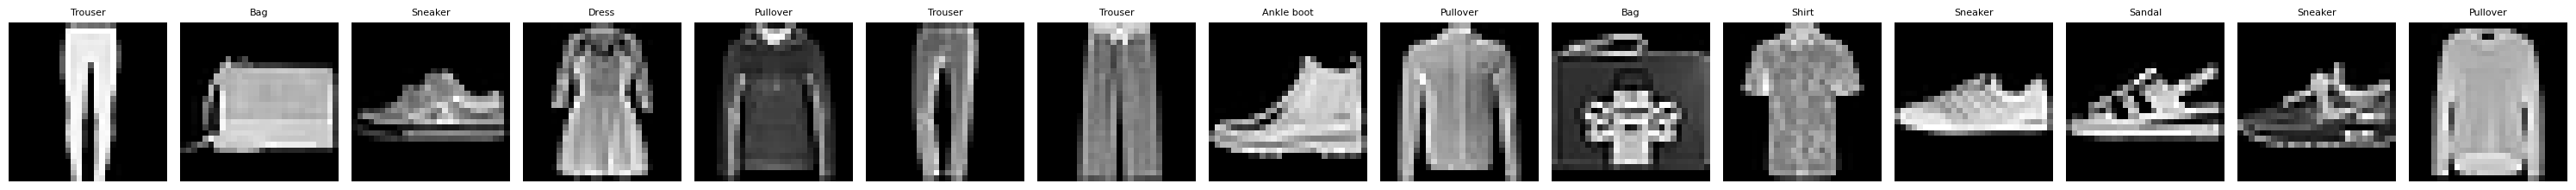

In [11]:
# show 15 random items
idx = utils.show_images(X, y, 15)

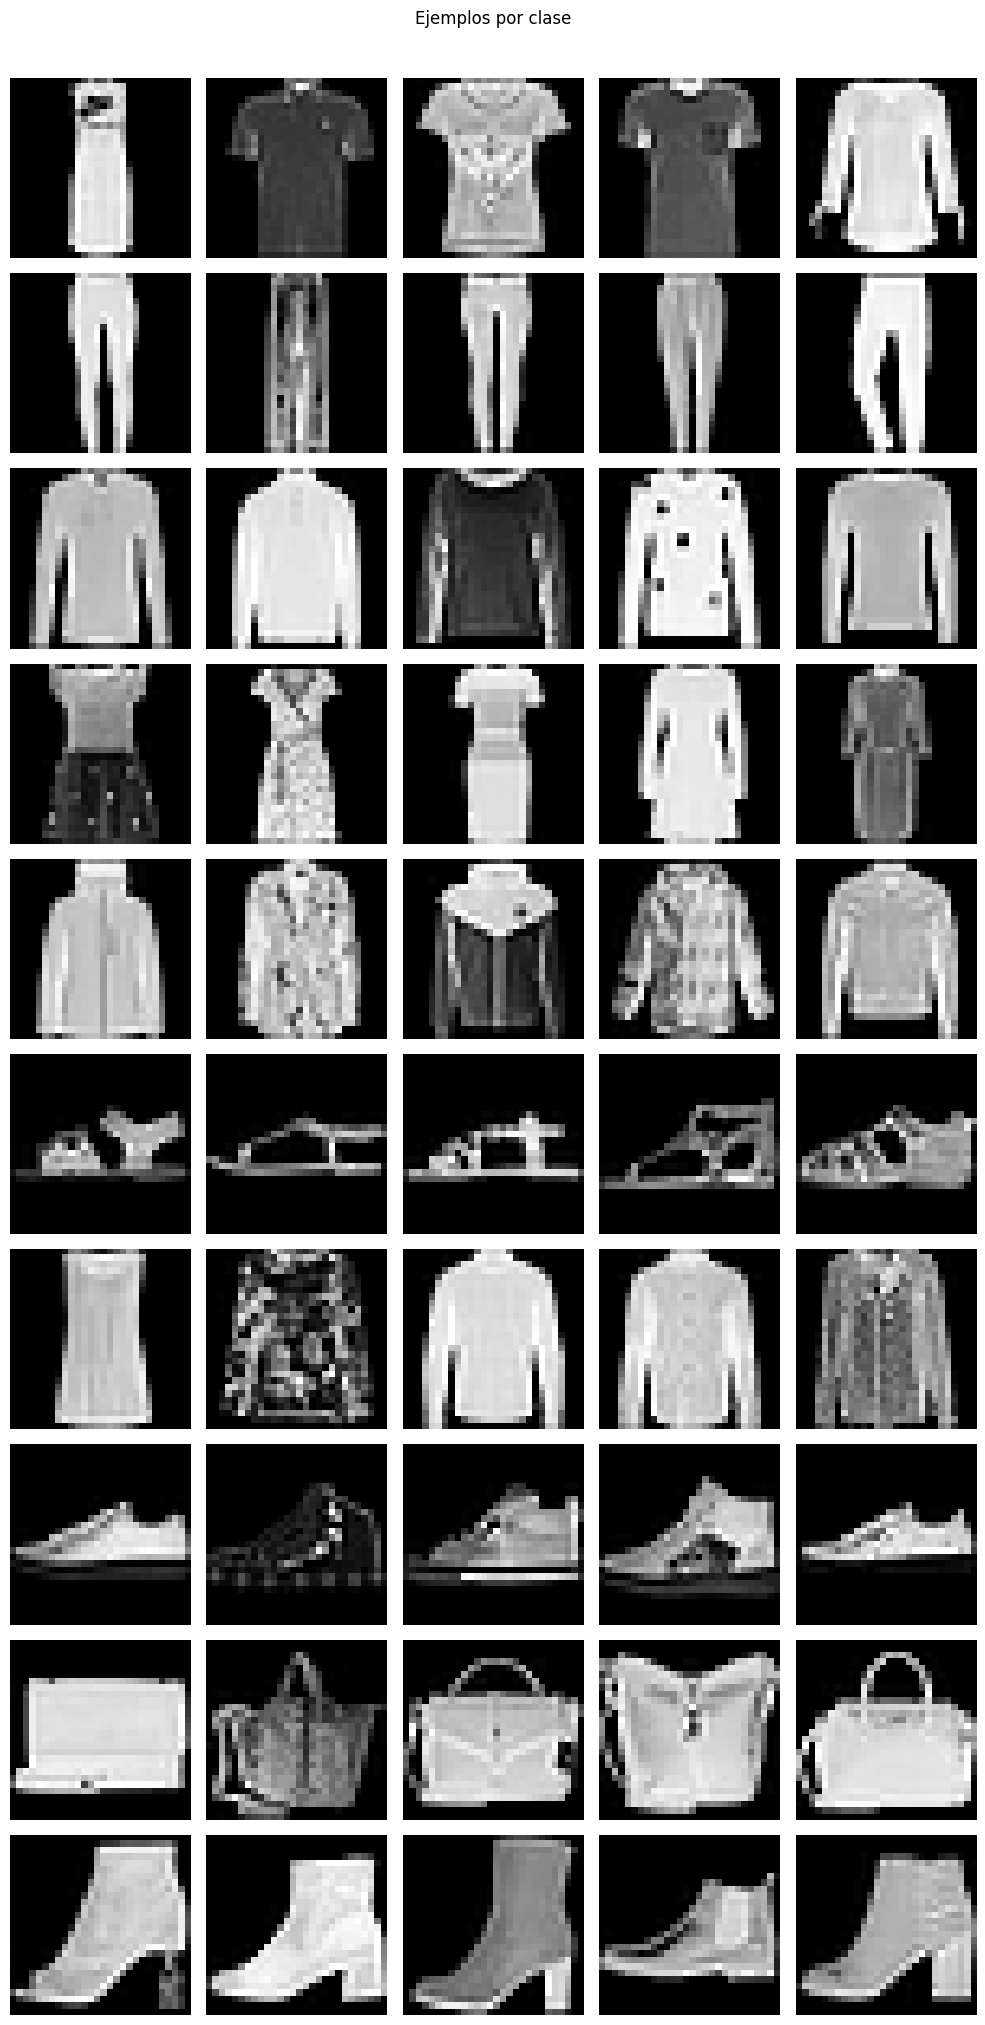

In [12]:
# show 5 items per class
utils.show_separate_classes(X, y, np.unique(y), 5)

In [13]:
# split data
train, test = data_splitting.random_stratified_split(df)

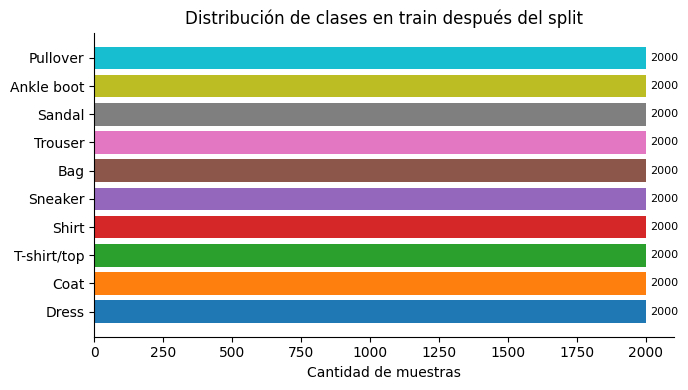

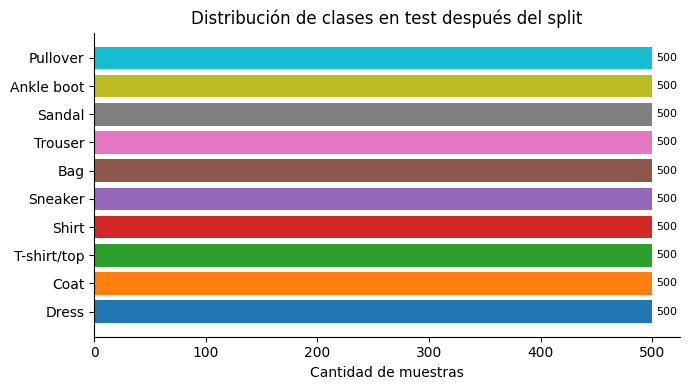

In [14]:
utils.show_proportions(train, title="Distribución de clases en train después del split")
utils.show_proportions(test, title="Distribución de clases en test después del split")

In [15]:
# separate features and label
y_train = train["label"].values
X_train = train.drop("label", axis=1)
y_test = test["label"].values
X_test = test.drop("label", axis=1)

## Ejercicio 2: Reducción de dimensionalidad

---

**Dataset:**   
**Objetivo:**

In [39]:
pca = models.PCA(k_components=784)

In [40]:
X_train_std = pca.fit_transform_scaler(X_train)
X_test_std = pca.transform_scaler(X_test)

_ = pca.fit_transform_pca(X_train_std)

Componentes para explicar 90% de varianza: 135


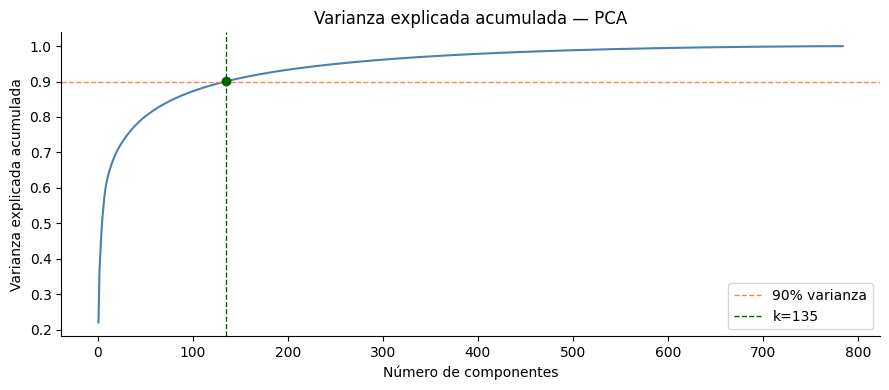

In [41]:
k_opt = utils.plot_explained_variance(pca)

In [42]:
pca_opt = models.PCA(k_components=k_opt)

In [43]:
X_train_std = pca_opt.fit_transform_scaler(X_train)
X_test_std = pca_opt.transform_scaler(X_test)

X_train_pca = pca_opt.fit_transform_pca(X_train_std)
X_test_pca = pca_opt.transform_pca(X_test_std)

In [44]:
X_train_pca.shape

(20000, 135)

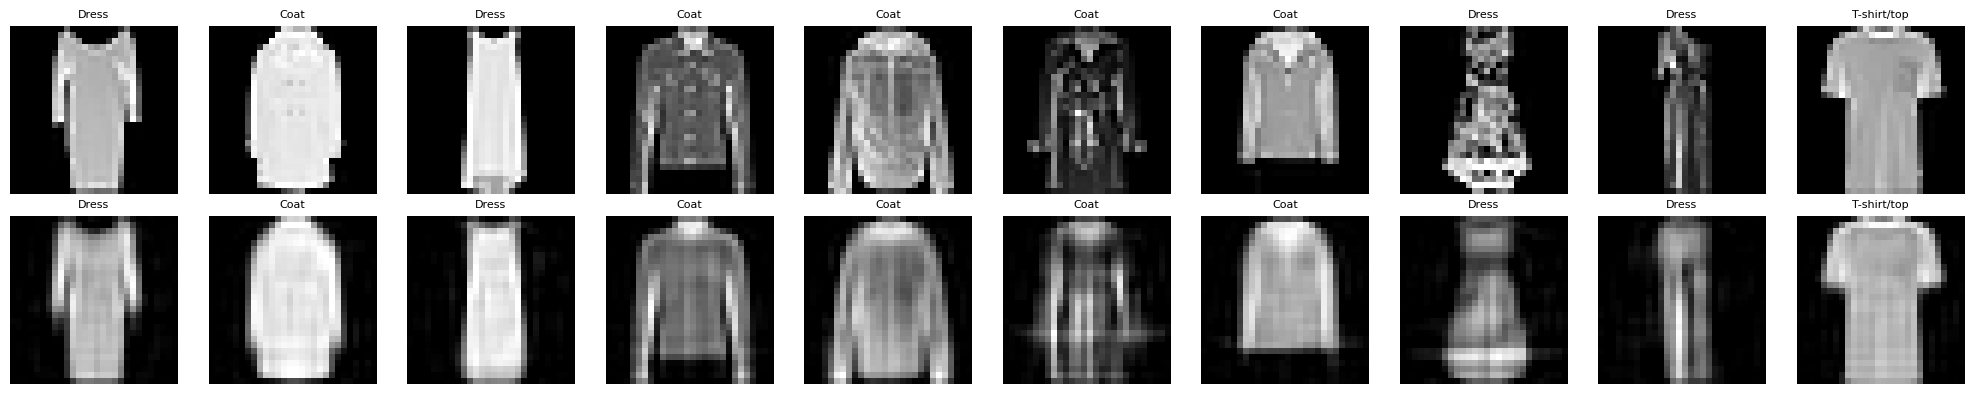

In [47]:
X_train_recon = utils.reconstruct(X_train_std, pca_opt, k_opt)
indices = np.random.default_rng(42).choice(len(X_test), 10, replace=False)
utils.plot_reconstruction(X_train.values, X_train_recon, y_train ,indices)

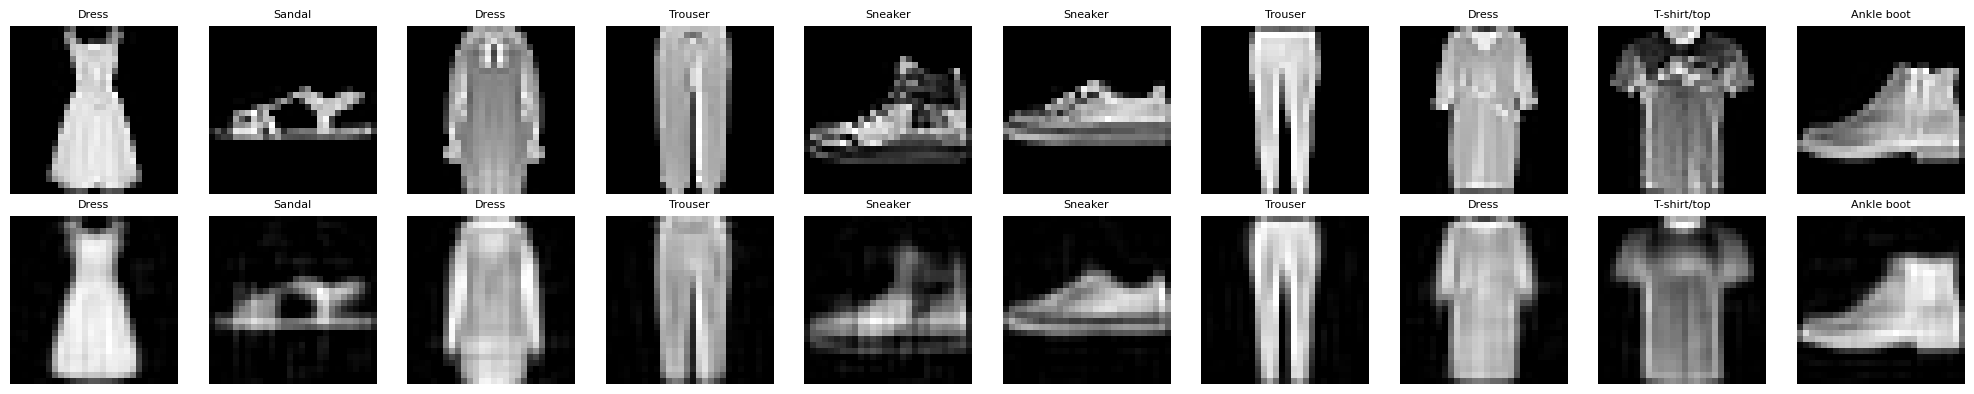

In [48]:
X_test_recon = utils.reconstruct(X_test_std, pca_opt, k_opt)
indices = np.random.default_rng(42).choice(len(X_test), 10, replace=False)
utils.plot_reconstruction(X_test.values, X_test_recon, y_test, indices)

In [23]:
INPUT_DIM = 784
LATENT_DIM = k_opt
device = device = ("cuda" if torch.cuda.is_available() else "cpu")

Epoch  10/50  train=0.0169  test=0.0166
Epoch  20/50  train=0.0130  test=0.0139
Epoch  30/50  train=0.0115  test=0.0118
Epoch  40/50  train=0.0103  test=0.0108
Epoch  50/50  train=0.0094  test=0.0103


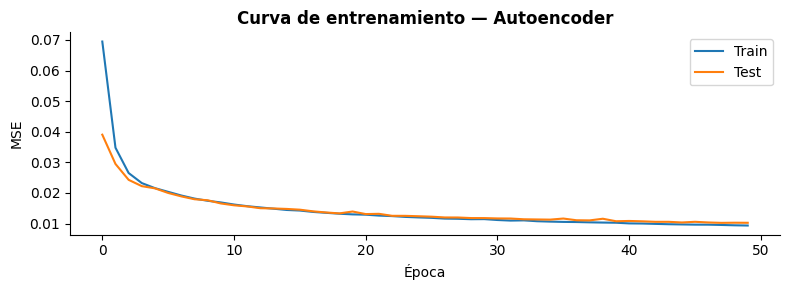

In [24]:
ae = models.AE(INPUT_DIM, LATENT_DIM).to(device)
train_losses, test_losses = trainer.train_AE(ae, X_train, X_test, device)
trainer.plot_loss(train_losses, test_losses)

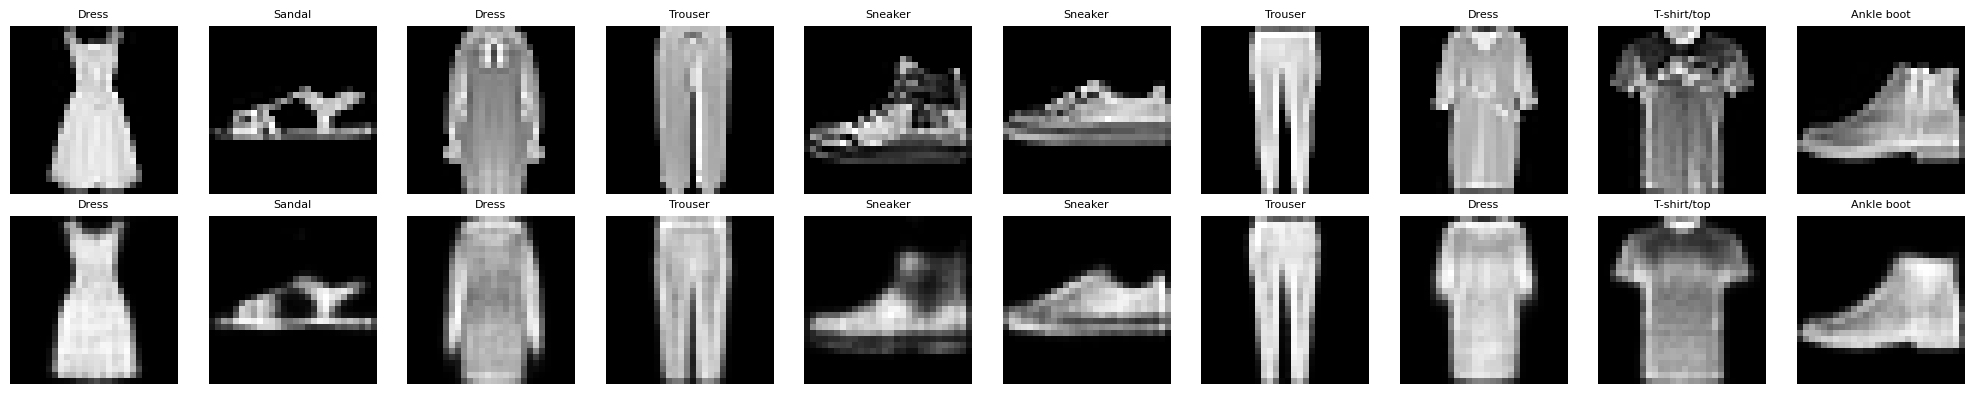

In [25]:
X_test_tensor = torch.tensor(X_test.to_numpy(), dtype=torch.float32).to(device)
X_test_recon_ae = ae(X_test_tensor).detach().cpu().numpy()
utils.plot_reconstruction(X_test, X_test_recon_ae, y_test, indices)   # mismos indices de 2b

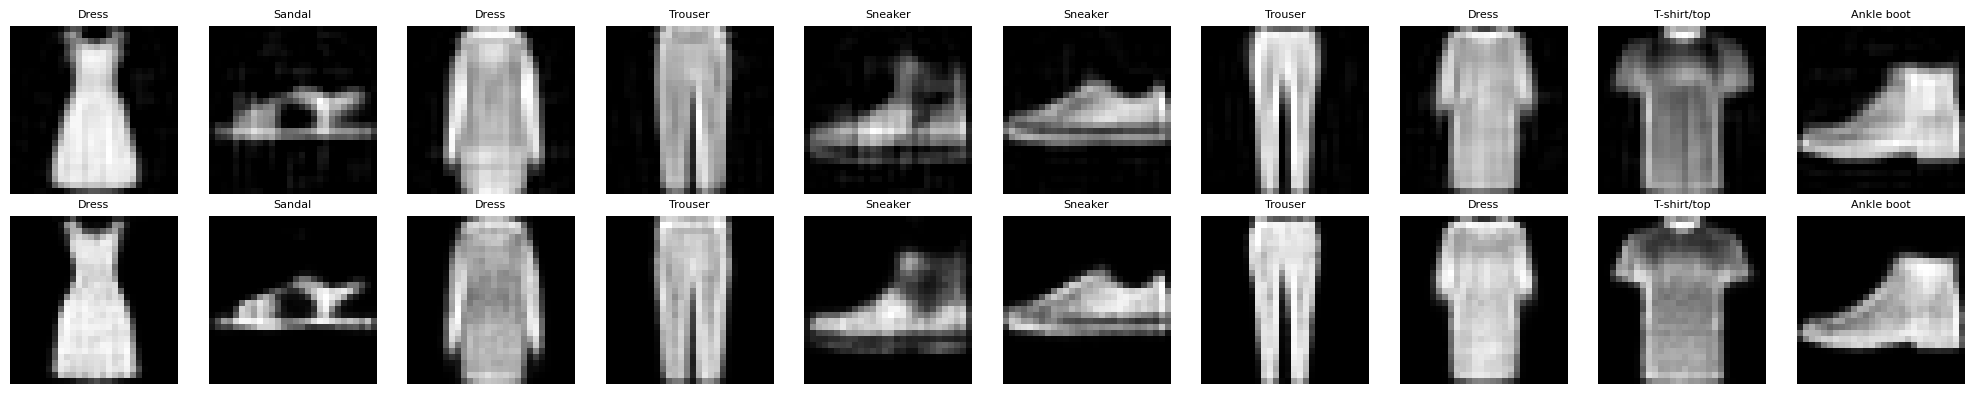

In [26]:
utils.plot_reconstruction(X_test_recon, X_test_recon_ae, y_test, indices)   # mismos indices de 2b

In [27]:
X_train_ae = trainer.encode_dataset(ae, X_train, device) #shape (n, K)
X_test_ae = trainer.encode_dataset(ae, X_test, device) #shape (m, K)

In [31]:
X_train_ae.shape

(20000, 135)

## Ejercicio 3: Clustering

---

**Dataset:**   
**Objetivo:**

In [53]:
X_sample, y_sample = data_splitting.stratified_sample(X_train_pca, y_train, n=3000)

In [62]:
# ── entrenar KMeans para K en [5, 15] ─────────────────────────────────────
inertias = {}
kms = {}

for k in range(5, 16):
    km = models.KMeans(k=k)
    km.fit(X_sample)
    kms[k] = km
    inertias[k] = km.inertia
    print(f"K={k:>2}  inertia={km.inertia:.2f}")

K= 5  inertia=1314542.15
K= 6  inertia=1239311.81
K= 7  inertia=1165907.43
K= 8  inertia=1131108.60
K= 9  inertia=1094007.55
K=10  inertia=1065756.11
K=11  inertia=1044823.14
K=12  inertia=1005594.43
K=13  inertia=982350.84
K=14  inertia=963675.79
K=15  inertia=965737.14


In [60]:
gmms = {}

for k in range(5, 16):
    gmm = models.GMM(k=k)
    gmm.fit(X_sample)
    gmms[k] = gmm
    print(f"K={k:>2}  ll={gmm.log_likelihoods[-1]:.2f}")

Convergió en iteración 75
K= 5  ll=-612636.16
Convergió en iteración 77
K= 6  ll=-610976.89
Convergió en iteración 86
K= 7  ll=-606537.26
Convergió en iteración 61
K= 8  ll=-604227.64
K= 9  ll=-601637.53
K=10  ll=-599803.46
K=11  ll=-597357.25
K=12  ll=-595272.90
K=13  ll=-594436.53
K=14  ll=-592813.13
K=15  ll=-591774.00
